# **Final Project: Comprehensive Exploratory Data Analysis (EDA)**

**Contributors:**

*   Michael Butnaru (ID: 206044711)
*   Karyn Arama (ID: 209702299)





## **Data Understanding: Crime Statistics Analysis**
---

The project focuses on a comprehensive analysis of crime statistics in Israel between the years 2020-2025. Our datasets are provided by data.gov.il, it provides granular details about reported incidents.

The dataset is rich with information, including geographical details such as police districts, regions, along with time-related data (year and quarter). Crucially, it categorizes crimes into specific statistical groups and types.

We aim to extract meaningful insights from this data, identify trends, and potentially forecast crime patterns, applying the analytical techniques learned throughout the course.

### **Column Details:**

*   **`FictiveIDNumber`**: A unique identifier for each incident. This is a pseudonymized ID to protect privacy.
*   **`Year`**: The year the incident occurred.
*   **`Quarter`**: The quarter of the year the incident occurred (Q1, Q2, Q3, Q4).
*   **`YeshuvKod`**: Numeric code for the City/Settlement where the incident occurred.
*   **`YeshuvName`**: The name of the City/Settlement.

*   **`PoliceDistrictKod`**: Numeric code for the police district.
*   **`PoliceDistrict`**: The name of the police district.
*   **`PoliceMerhavKod`**: Numeric code for the police region.
*   **`PoliceMerhav`**: The name of the police region.
*   **`PoliceStationKod`**: Numeric code for the police station.
*   **`PoliceStation`**: The name of the police station.
*   **`StatisticGroupKod`**: Numeric code for the primary crime statistical group.
*   **`StatisticGroup`**: The name of the primary crime statistical group.
*   **`StatisticTypeKod`**: Numeric code for the specific crime type within the statistical group.
*   **`StatisticType`**: The name of the specific crime type ('Assault', 'Burglary').
*   **`StatisticAreaKod`**: Numeric code for the area where the crime occurred.
*   **`StatisticArea`**: The name of the area where the crime occurred.



## **Identification of Potential Target Variables**

*   **`StatisticGroup` / `StatisticType`**: target variables if the goal is to predict the type of crime given other contextual information (location, time of year).
*   **Aggregated counts of incidents**: If the goal is to predict the number of crimes (total crimes, specific crime types) in a given `Yeshuv`, `PoliceDistrict`, `PoliceMerhav`, or `PoliceStation` for future periods. This would require aggregating the current data first.

For example, if we want to predict what *type* of crime is most likely to occur in a certain area, `StatisticType` could be a categorical target variable. If we are interested in predicting *where* certain crimes are most likely to occur, then geographical columns could be used as target variables after aggregation.

## **Data Loading and Library Setup**

In this project, we analyze crime data in Israel across multiple years (2021–2025).
The data is provided as separate CSV files, each representing a different year.

Before loading the data, we import the necessary Python libraries for:
- Data manipulation (pandas, numpy)
- Data visualization (matplotlib, seaborn)
- Handling Hebrew text in plots (arabic_reshaper and python-bidi)

These libraries allow us to clean, analyze, and visualize the data in a consistent and meaningful way.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
!pip install arabic_reshaper python-bidi
import arabic_reshaper
from bidi.algorithm import get_display

# datasets loading. reading all datasets and combining them
files = [
    "2020_hangashat_meyda_plili.csv",
    "2021_hangashat_meyda_plili.csv",
    "2022_hangashat_meyda_plili.csv",
    "2023_hangashat_meyda_plili.csv",
    "2024_hangashat_meyda_plili.csv",
    "2025_hangashat_meyda_plili.csv"]

# 'cp1255' encoding which is standard for Hebrew gov files
dfs = [pd.read_csv(f, encoding='cp1255') for f in files]
df = pd.concat(dfs, ignore_index=True)

#check if all files are loaded
print("Records per Year:")
print(df['Year'].value_counts().sort_index())
print(f"\nTotal rows loaded: {df.shape[0]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 6.7 MB/s eta 0:00:00
Records per Year:
Year
2020    391532
2021    415329
2022    414130
2023    424163
2024    399977
2025    299697
Name: count, dtype: int64

Total rows loaded: 2344828


# **Data Cleaning and Preparation**
---



## **Handling Records with Missing Location Data**

Some crime records in the dataset do not contain any geographical information such as settlement, police district, or police station.
These records cannot be associated with a specific location and therefore cannot be used for spatial or regional analysis.

First, we identify how many such records exist.
Then, we analyze their crime types to understand what kind of incidents they represent.
Finally, we remove these records from the main dataset to ensure data quality and consistency for later analysis.




In [ ]:
# columns that describe the geographical location of a crime
missing_location_cols = [
    'YeshuvKod',
    'Yeshuv',
    'PoliceDistrictKod',
    'PoliceDistrict',
    'PoliceMerhavKod',
    'PoliceMerhav',
    'PoliceStationKod',
    'PoliceStation',
    'municipalKod',
]

# boolean mask where all specified columns are null
df_missing_location = df[df[missing_location_cols].isnull().all(axis=1)] # filter rows where ALL specified columns are missing
print(f"Number of incidents with missing location data: {df_missing_location.shape[0]}") #first element of shape of table = number of rows

Number of incidents with missing location data: 9432


# We summed the crimes with missing locations by the crime type

Since our analysis focuses on spatial and regional crime patterns, these records cannot be meaningfully included and are therefore excluded from further location-based analysis.


In [ ]:
# Group the missing-location records by crime type
crime_type_counts = (
    df_missing_location
    .groupby(['StatisticTypeKod', 'StatisticType'])
    .size()
    .reset_index(name='count')
)

# Rename columns to Hebrew for presentation
crime_type_counts.rename(columns={
    'StatisticTypeKod': 'קוד עבירה',
    'StatisticType': 'שם עבירה',
    'count': 'מספר עבירות'
}, inplace=True)

# Display the crime types sorted by frequency
display(crime_type_counts.sort_values(by='מספר עבירות', ascending=False))


,קוד עבירה,שם עבירה,מספר עבירות
7,106,עבירות אחרות כלפי בטחון,1311
28,301,רצח,783
1,100,עבירות בטחון,718
5,104,הסתננות,665
2,101,בגידה ורגול,658
...,...,...,...
80,1002,עבירות מנהליות אחרות,1
81,1101,נשקתחמושת וחמרי נפץ,1
85,1200,שאר עבירות,1
87,10019,אי ציות לרמזור,1


To ensure data quality for subsequent analysis, we will now remove these rows from our main DataFrame

In [ ]:
# Create a boolean mask for rows where all location columns are missing
mask_completely_missing_location = df[missing_location_cols].isnull().all(axis=1)

# Remove these rows from the main DataFrame
df_cleaned_location = df[~mask_completely_missing_location].copy()

# Update the main DataFrame
df = df_cleaned_location

# Verify the result
print(f"Remaining records after removing missing-location rows: {df.shape[0]}")

Remaining records after removing missing-location rows: 2335396


# **Handling Missing `YeshuvName` by filling with `municipalName`**

Some crime records contain no settlement name (`Yeshuv`) but do include a municipal authority (`municipalName`).
Since both represent a geographical area, we use the municipal name to fill in missing settlement values.

This allows us to retain valuable records instead of discarding them, while still preserving a meaningful geographic reference.

After the imputation, any records that still lack a settlement name are removed, as they cannot be used for location-based analysis.


In [ ]:
# Count how many records are missing a settlement name before fixing
print(f"Number of missing Yeshuv before imputation: {df['Yeshuv'].isnull().sum()}")

# Fill missing Yeshuv values using municipalName
# This preserves records that have at least regional-level geographic information
df['Yeshuv'] = df['Yeshuv'].fillna(df['municipalName'])

# Check how many settlement names are still missing after filling
print(f"Number of missing Yeshuv after imputation: {df['Yeshuv'].isnull().sum()}")

# Remove rows that still do not have any settlement name
df.dropna(subset=['Yeshuv'], inplace=True)

# Final verification to ensure no missing settlement names remain
print(f"Number of missing Yeshuv after deletion: {df['Yeshuv'].isnull().sum()}")


Number of missing Yeshuv before imputation: 311966
Number of missing Yeshuv after imputation: 1191
Number of missing Yeshuv after deletion: 0


# **Removing Irrelevant and Redundant Columns**
The original dataset contains several columns that are not required for our analysis. Some columns are technical identifiers (such as pseudonymized IDs), while others are numeric codes that duplicate existing categorical fields.

To simplify the dataset and avoid redundancy, we remove columns that do not contribute meaningful analytical value.
This makes the DataFrame easier to work with and reduces the risk of confusion or incorrect usage in later stages.


*   **FictiveIDNumber**: This column contains a pseudonymized ID, which is not useful for our analytics
*   **PoliceDistrictKod**, **PoliceMerhavKod**, **PoliceStationKod**: These do not contribute to our conclutions.
*   **StatisticArea**: Similar to the above, this is a name for a statistical area, and its corresponding code (StatisticAreaKod) is also deleted.
*   **StatisticGroupKod**, **StatisticTypeKod**: These are codes for the crimes.



In [ ]:
# List of columns that are not needed for the analysis
# These include ID fields, numeric codes, and redundant location descriptors
columns_to_delete = [
    'FictiveIDNumber',      # Pseudonymized identifier, not useful for analysis
    'YeshuvKod',           # Numeric code for settlement
    'PoliceDistrictKod',   # Numeric code for police district
    'PoliceMerhavKod',     # Numeric code for police region
    'PoliceStationKod',   # Numeric code for police station
    'municipalKod',       # Numeric code for municipal authority
    'municipalName',      # No longer needed after filling Yeshuv
    'StatisticAreaKod',   # Numeric code for statistical area
    'StatisticArea',      # Name of statistical area
    'StatisticGroupKod',  # Numeric crime group code
    'StatisticTypeKod',   # Numeric crime type code
]

# Keep only columns that actually exist in the DataFrame
existing_columns_to_delete = [col for col in columns_to_delete if col in df.columns]

# Drop the unnecessary columns
if existing_columns_to_delete:
    df.drop(columns=existing_columns_to_delete, inplace=True)
    print(f"Successfully deleted columns: {', '.join(existing_columns_to_delete)}")
else:
    print("No specified columns found to delete.")

# Display the remaining columns to verify the structure
print("Columns after deletion:", df.columns.tolist())
display(df.head())


Successfully deleted columns: FictiveIDNumber, YeshuvKod, PoliceDistrictKod, PoliceMerhavKod, PoliceStationKod, municipalKod, municipalName, StatisticAreaKod, StatisticArea, StatisticGroupKod, StatisticTypeKod
Columns after deletion: ['Year', 'Quarter', 'Yeshuv', 'PoliceDistrict', 'PoliceMerhav', 'PoliceStation', 'StatisticGroup', 'StatisticType']


,Year,Quarter,Yeshuv,PoliceDistrict,PoliceMerhav,PoliceStation,StatisticGroup,StatisticType
0,2020,Q3,אור עקיבא,מחוז חוף,מרחב מנשה חוף,תחנת חדרה מחוז חוף,עבירות נגד גוף,(תקיפה (למעט עובדי ציבור
1,2020,Q1,חדרה,מחוז חוף,מרחב מנשה חוף,תחנת חדרה מחוז חוף,עבירות סדר ציבורי,עבירות הנוגעות לנחלת משפט
2,2020,Q2,אשדוד,מחוז דרומי,מרחב לכיש,תחנת אשדוד,עבירות נגד גוף,(תקיפה (למעט עובדי ציבור
3,2020,Q3,בת ים,מחוז תא,מרחב איילון החדש תא,תחנת בת ים איילון החדש,עבירות נגד גוף,(תקיפה (למעט עובדי ציבור
4,2020,Q1,צפת,מחוז צפון,מרחב כנרת צפון,תחנת צפת כנרת צפון,עבירות כלפי הרכוש,גניבה מתוך רכב


# **Defining Categorical Variables**

Several columns in the dataset represent categories rather than numerical values, such as settlements, police districts, and crime types.
Treating these columns as categorical variables improves memory efficiency, prevents invalid numerical operations, and enables meaningful grouping and aggregation.

In addition, the `Quarter` column is defined as an ordered categorical variable to preserve the natural time order (Q1 to Q4).


In [ ]:
# Define the order of the Quarter column (important for time-based analysis)
df['Quarter'] = pd.Categorical(df['Quarter'], categories=['Q1', 'Q2', 'Q3', 'Q4'], ordered=True)

# Convert location and crime-related columns to categorical types
df['Yeshuv'] = df['Yeshuv'].astype('category')
df['PoliceDistrict'] = df['PoliceDistrict'].astype('category')
df['PoliceMerhav'] = df['PoliceMerhav'].astype('category')
df['PoliceStation'] = df['PoliceStation'].astype('category')
df['StatisticGroup'] = df['StatisticGroup'].astype('category')
df['StatisticType'] = df['StatisticType'].astype('category')

# Display DataFrame information to verify data types
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2334205 entries, 0 to 2344827
Data columns (total 8 columns):
 #   Column          Dtype   
---  ------          -----   
 0   Year            int64   
 1   Quarter         category
 2   Yeshuv          category
 3   PoliceDistrict  category
 4   PoliceMerhav    category
 5   PoliceStation   category
 6   StatisticGroup  category
 7   StatisticType   category
dtypes: category(7), int64(1)
memory usage: 55.7 MB



# **Data Transformation**
---


## **Normalization by Population Size**

Raw crime counts alone are not sufficient for fair comparison between settlements, because cities and regional councils differ greatly in population size.
A large city will naturally report more crimes simply because it has more residents.

To address this, we integrate an external dataset containing population figures for each settlement.
The crime data (using the `Yeshuv` and, when needed, `municipalName` fields) is joined with the population dataset (`people_per_city.csv`).

This enables us to normalize crime counts and compute crime rates per 1,000 residents, allowing meaningful and unbiased comparison across different settlements.



In [ ]:
# Load the external dataset that contains population statistics per settlement
city_people = pd.read_csv("people_per_city.csv", encoding="cp1255")

# display a preview of the population data
display(city_people)


,YeshuvName,MunicipalName,total
0,לא רשום,,37422
1,שחר,מועצה אזורית לכיש,744
2,תירוש,מועצה אזורית מטה יהודה,426
3,"ניר ח""ן",מועצה אזורית לכיש,623
4,חצבה,מועצה אזורית הערבה התיכונה,822
...,...,...,...
1273,יהוד-מונוסון,,33499
1274,קרית ביאליק,,51755
1275,קרית ים,,49670
1276,הוד השרון,,71208


In [ ]:
city_people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1278 entries, 0 to 1277
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   YeshuvName     1278 non-null   object
 1   MunicipalName  1278 non-null   object
 2   total          1278 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 30.1+ KB


## First-Stage Population Matching (Settlement Level)

Before merging the crime data with the population dataset, we standardize the settlement names to ensure reliable matching.
Differences in whitespace, empty strings, or placeholder values such as "nan" or "none" can cause valid matches to fail.

We then perform a left join between the crime dataset and the population dataset based on settlement names.
This assigns a population value to each crime record whenever a direct match is available.

After the merge, we identify which settlements were successfully matched and remove them from the population table.
The remaining entries will later be used to handle regional councils that require municipal-level aggregation.


In [ ]:
# Normalize settlement names by converting to string and stripping whitespace
df['Yeshuv'] = df['Yeshuv'].astype(str).str.strip()
city_people['YeshuvName'] = city_people['YeshuvName'].astype(str).str.strip()

# Replace invalid or empty strings with proper NaN values
df.loc[df['Yeshuv'].str.lower().isin(['nan', 'none', '']), 'Yeshuv'] = pd.NA
city_people.loc[city_people['YeshuvName'].str.lower().isin(['nan', 'none', '']), 'YeshuvName'] = pd.NA

# Perform a left join to attach population data to each settlement in the crime dataset
df = df.merge(
    city_people[['YeshuvName', 'total']],
    left_on='Yeshuv',
    right_on='YeshuvName',
    how='left')

# Remove the duplicate key column and rename the population column
df.drop(columns=['YeshuvName'], inplace=True)
df.rename(columns={'total': 'population_total'}, inplace=True)

# Identify which settlements were successfully matched
used_yeshuv = df['Yeshuv'].dropna().unique()

# Remove matched settlements from the population table
# The remaining rows correspond mainly to regional council components
city_people.drop(
    city_people[city_people['YeshuvName'].isin(used_yeshuv)].index,
    inplace=True
)

# reset the index after deleting
city_people.reset_index(drop=True, inplace=True)

# Display remaining unmatched population records
display(city_people)

# aggregate remaining population by municipal (for regional councils)
city_people_by_municipality = (
    city_people.groupby('MunicipalName', as_index=False)['total'].sum()
)

display(city_people_by_municipality)


,YeshuvName,MunicipalName,total
0,לא רשום,,37422
1,שחר,מועצה אזורית לכיש,744
2,תירוש,מועצה אזורית מטה יהודה,426
3,"ניר ח""ן",מועצה אזורית לכיש,623
4,חצבה,מועצה אזורית הערבה התיכונה,822
...,...,...,...
1078,נוב,מועצה אזורית גולן,1179
1079,עין זיוון,מועצה אזורית גולן,569
1080,נאות מועצה אזורית גולן,מועצה אזורית גולן,796
1081,רמת מגשימים,מועצה אזורית גולן,893


,MunicipalName,total
0,,357326
1,מועצה אזורית אל קסום,17834
2,מועצה אזורית אל-בטוף,9292
3,מועצה אזורית אלונה,2240
4,מועצה אזורית אשכול,17698
5,מועצה אזורית באר טוביה,21901
6,מועצה אזורית בוסתן-אל-מרג',9098
7,מועצה אזורית בני שמעון,12440
8,מועצה אזורית ברנר,8464
9,מועצה אזורית גדרות,5138


In [ ]:
display(df)

,Year,Quarter,Yeshuv,PoliceDistrict,PoliceMerhav,PoliceStation,StatisticGroup,StatisticType,population_total
0,2020,Q3,אור עקיבא,מחוז חוף,מרחב מנשה חוף,תחנת חדרה מחוז חוף,עבירות נגד גוף,(תקיפה (למעט עובדי ציבור,27901.0
1,2020,Q1,חדרה,מחוז חוף,מרחב מנשה חוף,תחנת חדרה מחוז חוף,עבירות סדר ציבורי,עבירות הנוגעות לנחלת משפט,114781.0
2,2020,Q2,אשדוד,מחוז דרומי,מרחב לכיש,תחנת אשדוד,עבירות נגד גוף,(תקיפה (למעט עובדי ציבור,260968.0
3,2020,Q3,בת ים,מחוז תא,מרחב איילון החדש תא,תחנת בת ים איילון החדש,עבירות נגד גוף,(תקיפה (למעט עובדי ציבור,160621.0
4,2020,Q1,צפת,מחוז צפון,מרחב כנרת צפון,תחנת צפת כנרת צפון,עבירות כלפי הרכוש,גניבה מתוך רכב,41868.0
...,...,...,...,...,...,...,...,...,...
2334200,2025,Q3,קרית מלאכי,מחוז דרומי,מרחב לכיש,תחנת ק.מלאכי לכיש,עבירות סדר ציבורי,עבירות הנוגעות לנחלת משפט,30000.0
2334201,2025,Q2,חורפיש,מחוז צפון,מרחב כנרת צפון,תחנת מעלות תרשיחא כנרת צפון,עבירות סדר ציבורי,עבירות נגד הסדר הצבורי,7139.0
2334202,2025,Q2,טמרה,מחוז צפון,מרחב גליל צפון,תחנת טמרה גליל צפון,עבירות כלפי הרכוש,גרימת נזק לרכוש בזדון,37764.0
2334203,2025,Q3,מקום אחר,מחוז שי,מרחב יהודה שי,תחנת חברון יהודה,עבירות כלפי הרכוש,סחר והחזקה בחלקי רכב גנובים,NaN


## Second-Stage Population Matching (Regional Councils)

After matching settlements that have direct population data, some records still remain without a population value.
These records usually belong to small settlements that are part of regional councils.

To handle this, we merge the crime data with a population table aggregated by municipal authority.
This allows us to assign a total population value to each regional council, ensuring that no valid geographic area is excluded from the analysis.

Finally, we remove any records that still lack population information, as they cannot be normalized.


In [ ]:
# Remove invalid or irrelevant settlement entries
to_drop = ['מקום אחר', 'ישוב פלסטיני', 'מקום', 'מועצה אזורית עמק לוד']
df = df[~df['Yeshuv'].isin(to_drop)]

# Merge the municipal-level population data into the crime dataset
df = df.merge(
    city_people_by_municipality[['MunicipalName', 'total']],
    left_on='Yeshuv',
    right_on='MunicipalName',
    how='left'
)

# Fill missing population values using the municipal totals
df['population_total'] = df['population_total'].fillna(df['total'])

# Drop temporary columns added during the merge
df.drop(columns=['MunicipalName', 'total'], inplace=True)

# Remove all rows that still have no population information
df = df.dropna(subset=['population_total'])

# Verify that all remaining records have valid population values
print(f"Final count of missing population values: {df['population_total'].isnull().sum()}")

# Display the cleaned and enriched dataset
display(df)


Final count of missing population values: 0


,Year,Quarter,Yeshuv,PoliceDistrict,PoliceMerhav,PoliceStation,StatisticGroup,StatisticType,population_total
0,2020,Q3,אור עקיבא,מחוז חוף,מרחב מנשה חוף,תחנת חדרה מחוז חוף,עבירות נגד גוף,(תקיפה (למעט עובדי ציבור,27901.0
1,2020,Q1,חדרה,מחוז חוף,מרחב מנשה חוף,תחנת חדרה מחוז חוף,עבירות סדר ציבורי,עבירות הנוגעות לנחלת משפט,114781.0
2,2020,Q2,אשדוד,מחוז דרומי,מרחב לכיש,תחנת אשדוד,עבירות נגד גוף,(תקיפה (למעט עובדי ציבור,260968.0
3,2020,Q3,בת ים,מחוז תא,מרחב איילון החדש תא,תחנת בת ים איילון החדש,עבירות נגד גוף,(תקיפה (למעט עובדי ציבור,160621.0
4,2020,Q1,צפת,מחוז צפון,מרחב כנרת צפון,תחנת צפת כנרת צפון,עבירות כלפי הרכוש,גניבה מתוך רכב,41868.0
...,...,...,...,...,...,...,...,...,...
2175066,2025,Q2,בסמת טבעון,מחוז חוף,מרחב אשר חוף,תחנת זבולון מחוז חוף,עבירות סדר ציבורי,עבירות נגד הסדר הצבורי,8524.0
2175067,2025,Q3,קרית מלאכי,מחוז דרומי,מרחב לכיש,תחנת ק.מלאכי לכיש,עבירות סדר ציבורי,עבירות הנוגעות לנחלת משפט,30000.0
2175068,2025,Q2,חורפיש,מחוז צפון,מרחב כנרת צפון,תחנת מעלות תרשיחא כנרת צפון,עבירות סדר ציבורי,עבירות נגד הסדר הצבורי,7139.0
2175069,2025,Q2,טמרה,מחוז צפון,מרחב גליל צפון,תחנת טמרה גליל צפון,עבירות כלפי הרכוש,גרימת נזק לרכוש בזדון,37764.0


## Feature Engineering: Crime Rate per 1,000 Residents

After each crime record has been associated with a population value, we can construct a normalized crime metric.

We aggregate the data by settlement (`Yeshuv`) to compute:
- The total number of crimes in each settlement
- The population size of each settlement

Using these values, we calculate the crime rate per 1,000 residents.
This feature allows fair comparison between settlements of very different sizes and serves as the main quantitative measure in the analysis.


In [ ]:
# Aggregate data by settlement to calculate total crimes and population
crimes_per_capita_df = df.groupby('Yeshuv').agg(
    total_crimes=('Yeshuv', 'count'),        # Number of crime records
    population=('population_total', 'max')  # Population of the settlement
).reset_index()

# Compute crime rate per 1,000 residents
crimes_per_capita_df['crimes_per_1000'] = (
    crimes_per_capita_df['total_crimes'] / crimes_per_capita_df['population']
) * 1000

# Round values for readability
crimes_per_capita_df['crimes_per_1000'] = crimes_per_capita_df['crimes_per_1000'].round(3)

# Remove invalid population entries
crimes_per_capita_df = crimes_per_capita_df[crimes_per_capita_df['population'] > 0]

# Sort settlements by highest crime rate
crimes_per_capita_df = crimes_per_capita_df.sort_values(
    by='crimes_per_1000',
    ascending=False
)
# Display the normalized crime-rate table
display(crimes_per_capita_df)


,Yeshuv,total_crimes,population,crimes_per_1000
108,מועצה אזורית גזר,4480,571.0,7845.884
106,מועצה אזורית באר טוביה,5915,1276.0,4635.580
110,מועצה אזורית לכיש,3203,881.0,3635.641
112,מועצה אזורית שפיר,2601,1022.0,2545.010
111,מועצה אזורית מגידו,2303,1009.0,2282.458
...,...,...,...,...
13,אלקנה,224,4677.0,47.894
170,קרית יערים,365,7894.0,46.238
87,כפר כמא,172,3759.0,45.757
104,מודיעין עילית,4183,92263.0,45.338


# **Preliminary Exploratory Analysis**

---




### Function to fix hebrew on graph

In [ ]:
def fix_hebrew_xticks(ax):
    labels = [item.get_text() for item in ax.get_xticklabels()]
    rtl_labels = [get_display(arabic_reshaper.reshape(label)) for label in labels]
    ax.set_xticklabels(rtl_labels)

## **Crime Distribution by Category**
Before normalizing by population, we first explore the raw distribution of crimes across different statistical groups.
This provides an overall picture of which types of crime are most frequent in the dataset.

These results are based on absolute crime counts and do not yet account for differences in population size between settlements.
They serve as an initial overview of crime composition in Israel.

/tmp/ipython-input-1610773089.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rtl_labels)


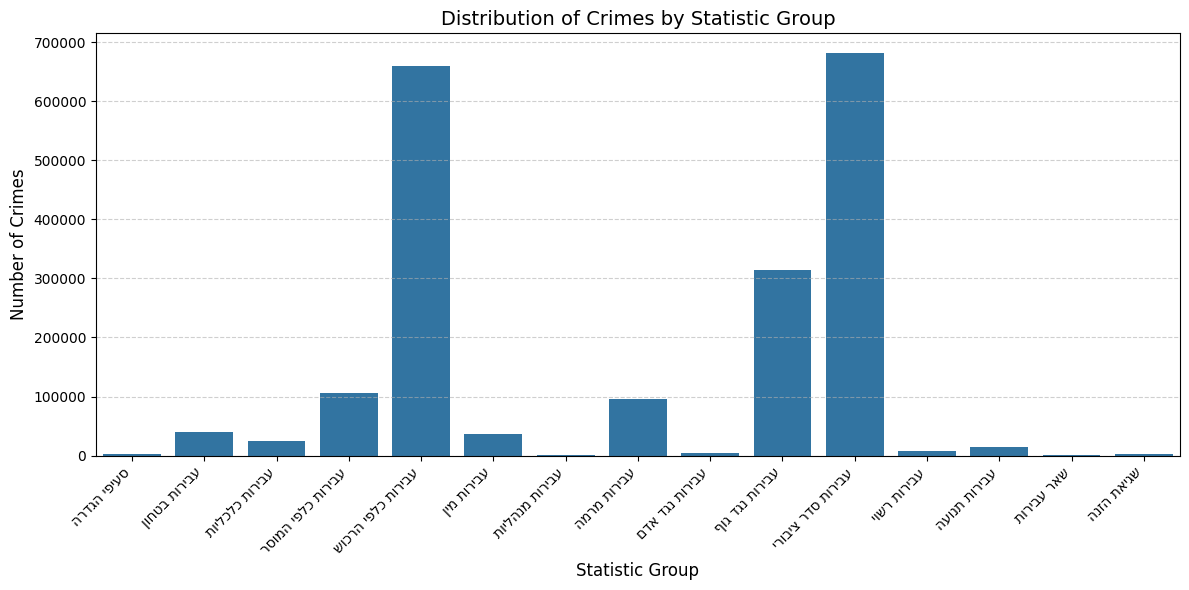

In [ ]:
plt.figure(figsize=(12,6))

# Count how many crimes belong to each crime group
group_counts = (
    df['StatisticGroup']
    .value_counts()
    .sort_values(ascending=False)
)

# Plot the distribution
ax = sns.barplot(
    x=group_counts.index,
    y=group_counts.values
)

# Fix Hebrew right-to-left labels
fix_hebrew_xticks(ax)

# Add titles and labels
plt.title('Distribution of Crimes by Statistic Group', fontsize=14)
plt.xlabel('Statistic Group', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



## **Most Frequent Crime Types**

In addition to broad crime groups, we also examine the most frequent specific crime types.
This analysis shows which offenses occur most often across all settlements, regardless of population size.

These results are based on absolute counts and provide insight into the dominant types of criminal activity in the dataset.


#Top 10 Most Frequent Crime Types

/tmp/ipython-input-1610773089.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rtl_labels)


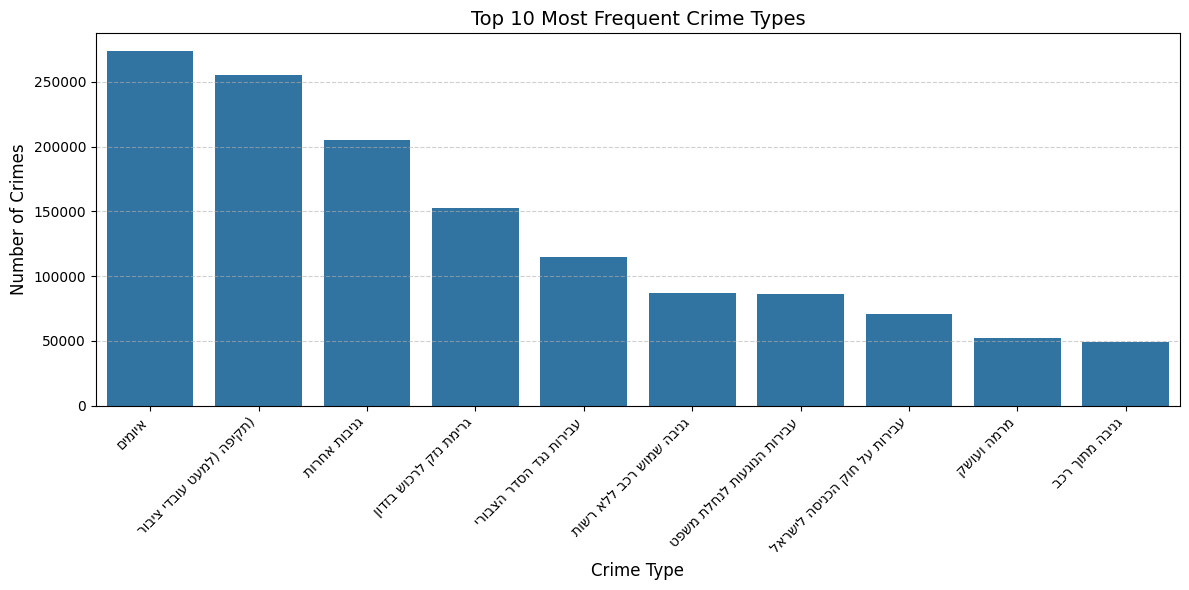

In [ ]:
# Identify the top 10 most frequent crime types
top_10_types = df['StatisticType'].value_counts().head(10)

# Create a bar chart showing their frequencies
plt.figure(figsize=(12,6))
ax = sns.countplot(
    data=df[df['StatisticType'].isin(top_10_types.index)],
    x='StatisticType',
    order=top_10_types.index
)

# Fix Hebrew right-to-left labels
fix_hebrew_xticks(ax)

# Add titles and labels
plt.title('Top 10 Most Frequent Crime Types', fontsize=14)
plt.xlabel('Crime Type', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


## **Crime Trend Over Time**
To understand how crime has evolved over the years, we analyze the total number of reported incidents per year.
This allows us to observe long-term trends, such as increases or decreases in crime levels across the country.

These values represent absolute crime counts and provide a high-level temporal overview of criminal activity in Israel.

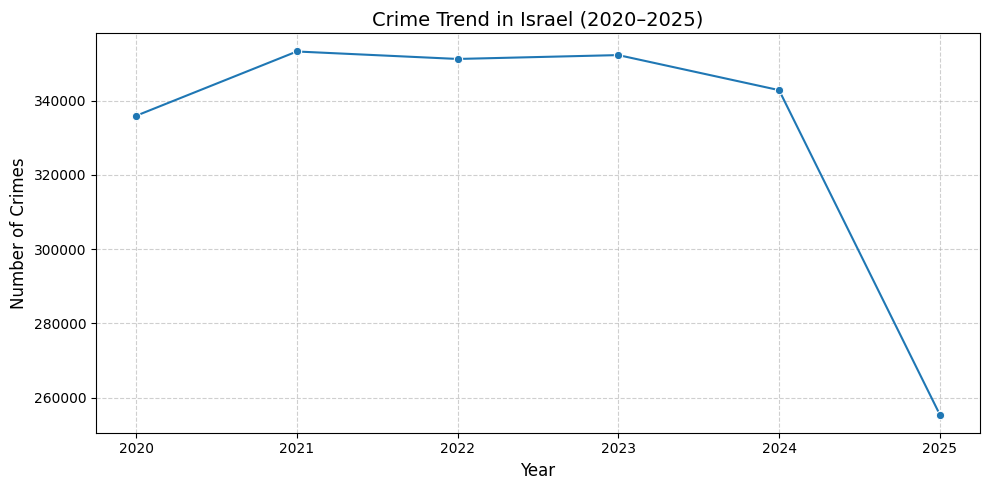

In [ ]:
# Aggregate the number of crimes by year
crimes_by_year = df.groupby('Year').size().reset_index(name='Total Crimes')

# Plot the yearly crime trend
plt.figure(figsize=(10,5))
sns.lineplot(
    data=crimes_by_year,
    x='Year',
    y='Total Crimes',
    marker='o'
)

# Set x-axis ticks to show all years
plt.xticks(crimes_by_year['Year'])

# Add titles and labels
plt.title('Crime Trend in Israel (2020–2025)', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Crimes', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



## **Separating Regional Councils and Urban Settlements**

Regional councils and urban settlements differ significantly in both population structure and geographic organization.
Regional councils consist of multiple small communities, while cities and towns represent a single population unit.

To avoid misleading comparisons, we separate these two types of entities and analyze them independently.
This allows us to identify high-crime regional councils and high-crime urban settlements without mixing fundamentally different administrative structures.



/tmp/ipython-input-1610773089.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rtl_labels)


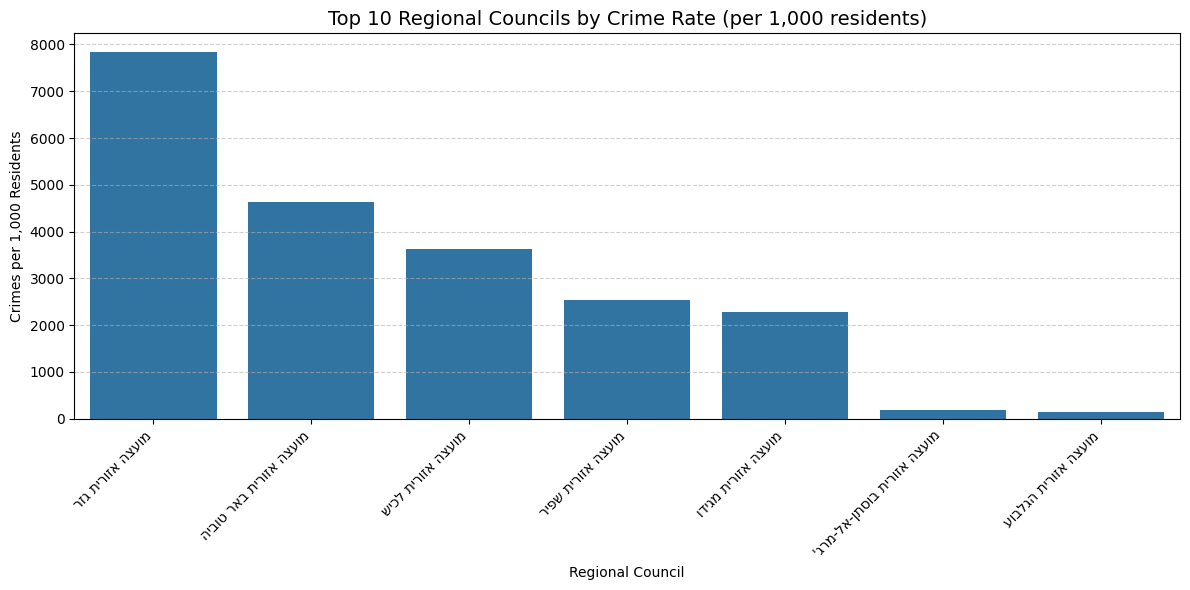

/tmp/ipython-input-1610773089.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(rtl_labels)


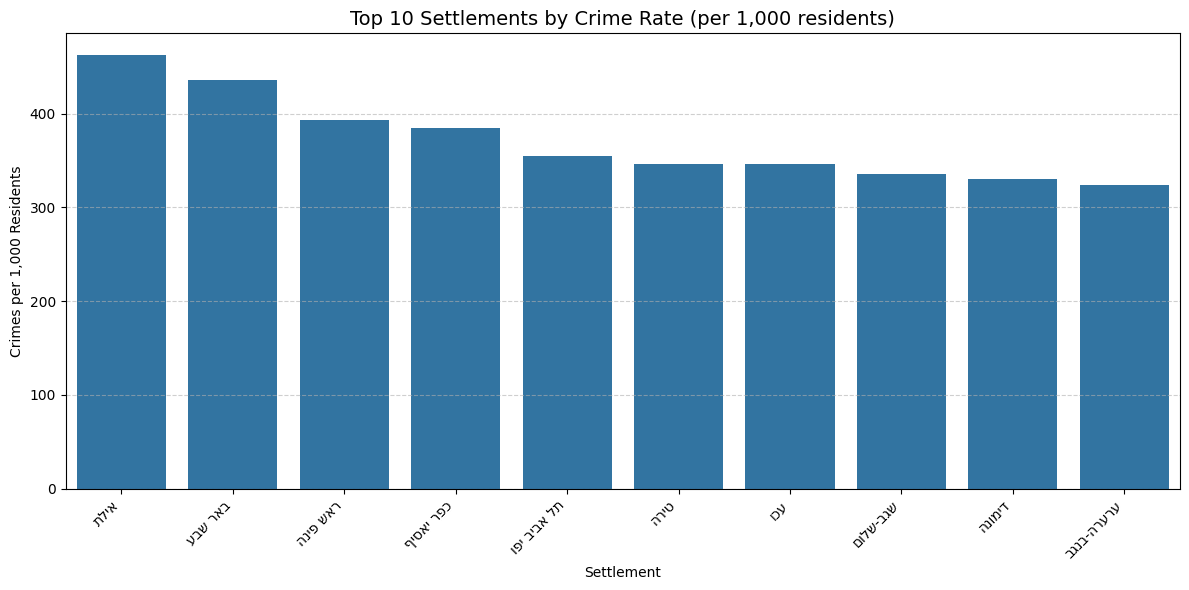

In [ ]:
# Separate regional councils (names starting with "מועצה אזורית")
regional_df = crimes_per_capita_df[
    crimes_per_capita_df['Yeshuv'].str.startswith('מועצה אזורית', na=False)
]

# Separate regular urban settlements (cities, towns, villages)
cities_df = crimes_per_capita_df[
    ~crimes_per_capita_df['Yeshuv'].str.startswith('מועצה אזורית', na=False)
]

# Select the top 10 regional councils by crime rate
top_regional = regional_df.sort_values('crimes_per_1000', ascending=False).head(10)

# Plot top 10 regional councils
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=top_regional,
    x='Yeshuv',
    y='crimes_per_1000'
)

fix_hebrew_xticks(ax)

plt.title('Top 10 Regional Councils by Crime Rate (per 1,000 residents)', fontsize=14)
plt.xlabel('Regional Council')
plt.ylabel('Crimes per 1,000 Residents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Select the top 10 urban settlements by crime rate
top_cities = cities_df.sort_values('crimes_per_1000', ascending=False).head(10)

# Plot top 10 settlements
plt.figure(figsize=(12,6))
ax = sns.barplot(
    data=top_cities,
    x='Yeshuv',
    y='crimes_per_1000'
)

fix_hebrew_xticks(ax)

plt.title('Top 10 Settlements by Crime Rate (per 1,000 residents)', fontsize=14)
plt.xlabel('Settlement')
plt.ylabel('Crimes per 1,000 Residents')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



## **Crime Groups by Year (Pivot Table and Heatmap)**

To analyze how different types of crime evolve over time, we construct a pivot table that summarizes the number of crimes per year for each crime group.

This creates a two-dimensional view (Year × Crime Group) that allows us to detect trends, shifts, and anomalies across multiple crime categories.
We visualize this pivot table using a heatmap to make patterns easier to identify.


/tmp/ipython-input-1436533886.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_year_group = pd.pivot_table(


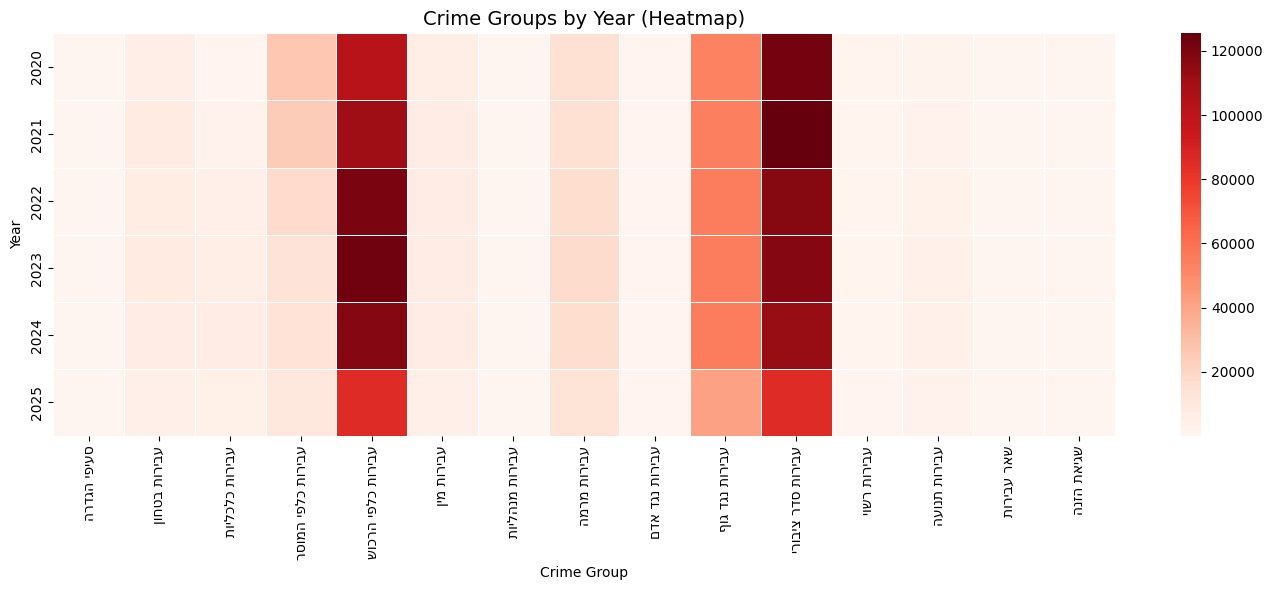

In [ ]:
# Create a pivot table: rows = Year, columns = StatisticGroup, values = number of crimes
pivot_year_group = pd.pivot_table(
    df,
    index='Year',
    columns='StatisticGroup',
    values='StatisticType',
    aggfunc='count',
    fill_value=0
)

# Plot the heatmap
plt.figure(figsize=(14,6))
ax = sns.heatmap(
    pivot_year_group,
    cmap='Reds',
    linewidths=0.5
)

# Fix Hebrew labels for columns
fix_hebrew_xticks(ax)

plt.title('Crime Groups by Year (Heatmap)', fontsize=14)
plt.xlabel('Crime Group')
plt.ylabel('Year')
plt.tight_layout()
plt.show()


## **Distribution of Crime Rates Across Settlements**

After computing the crime rate per 1,000 residents for each settlement, we analyze how these values are distributed across all settlements.

This histogram allows us to determine whether crime rates are evenly spread or whether a small number of settlements exhibit unusually high values.
It also helps identify outliers and assess the overall variability in crime intensity across the country.





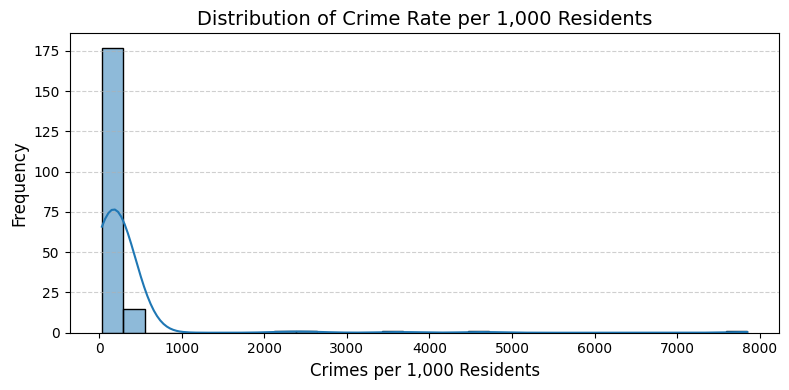

In [ ]:
# Create a figure for the histogram
plt.figure(figsize=(8,4))

# Plot the distribution of crime rates per 1,000 residents
# Each bar represents how many settlements fall within a given crime-rate range
sns.histplot(
    crimes_per_capita_df['crimes_per_1000'],
    bins=30,
    kde=True  # Add a smooth density curve to show the distribution shape
)

# Add title and axis labels
plt.title('Distribution of Crime Rate per 1,000 Residents', fontsize=14)
plt.xlabel('Crimes per 1,000 Residents', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adjust layout so labels do not overlap
plt.tight_layout()

# Display the plot
plt.show()



## **Distribution of Settlement Population Sizes**

This histogram shows how population sizes are distributed across all settlements in the dataset.

Understanding the population distribution is essential for interpreting normalized crime rates, since very small settlements can produce extremely high crime rates per capita even with a small number of incidents.
This visualization helps explain why the crime-rate distribution is highly skewed.


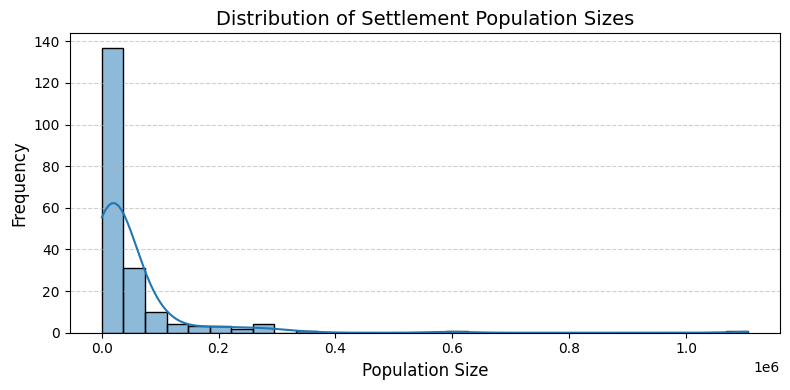

In [ ]:
# Create a figure for the population size distribution
plt.figure(figsize=(8,4))

# Plot a histogram of settlement population sizes
# Each bar represents how many settlements fall into a given population range
sns.histplot(
    crimes_per_capita_df['population'],
    bins=30,
    kde=True  # Add a smooth curve to show the overall distribution shape
)

# Add title and axis labels
plt.title('Distribution of Settlement Population Sizes', fontsize=14)
plt.xlabel('Population Size', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Add a grid for better readability
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Adjust layout to prevent label overlap
plt.tight_layout()

# Display the plot
plt.show()



## **Crimes per quarter**
We grouped the crimes by quarter. calculated the total number of crimes per quarter and divided it by the number of years to obtain the average crimes per quarter per year.
Finally, we visualized the results using a bar chart to highlight seasonal crime patterns.

/tmp/ipython-input-3879152902.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  quarter_counts = df_period.groupby('Quarter').size()


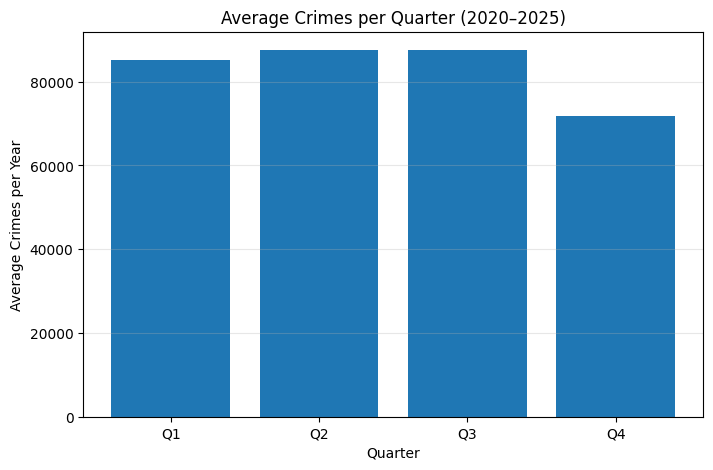

In [ ]:
# Filter years
df_period = df[df['Year'].between(2020, 2025)]

# Count crimes per quarter across all years
quarter_counts = df_period.groupby('Quarter').size()

# Number of years in data (DO NOT hardcode)
n_years = df_period['Year'].nunique()

# Average per quarter per year
quarter_avg = (quarter_counts / n_years).reindex(['Q1', 'Q2', 'Q3', 'Q4'])

# Plot
plt.figure(figsize=(8, 5))
plt.bar(quarter_avg.index, quarter_avg.values)
plt.title('Average Crimes per Quarter (2020–2025)')
plt.xlabel('Quarter')
plt.ylabel('Average Crimes per Year')
plt.grid(axis='y', alpha=0.3)
plt.show()

## **Summary and Key Insights from the Analysis**

In this project, we analyzed a large scale crime dataset in Israel covering the years 2020–2025.
The analysis included data cleaning, transformation, population-based normalization, and multiple visualizations in order to identify temporal, geographic, and categorical crime patterns.

**Central Crime Types**

The results show that a small number of crime groups account for a significant portion of all recorded crimes.
These central crime types are likely more frequent because they include everyday offenses, such as property related or public order crimes, which naturally occur more often than severe but rare crimes.

**Crime Trends Over the Years**

When examining crime trends over time, we observe relatively high and stable crime levels during 2020–2022.
This period overlaps with the COVID-19 pandemic, which may have contributed to changes in social behavior, economic stress, and law enforcement dynamics, potentially affecting crime rates.
The sharp decline in 2025 is likely caused by incomplete or missing crime reports, rather than an actual reduction in crime.

**Geographic Patterns and Regional Councils**

After applying population normalization (crimes per 1,000 residents), several regional councils and settlements stand out with high crime rates.
This does not necessarily mean they have the highest number of crimes in absolute terms, but rather that their population size is relatively small, which amplifies the crime rate per capita.
This demonstrates why normalization is essential for fair geographic comparisons, while also emphasizing the need for careful interpretation in low-population areas.

**Seasonal (Quarterly) Trends**

The quarterly analysis reveals a clear seasonal pattern.
Crime levels are generally higher in Q2 and Q3, which may be related to increased social activity, holidays, and favorable weather conditions.
In contrast, Q4 shows lower average crime levels, possibly due to reduced outdoor activity and seasonal factors.

**Overall Conclusion**

Overall, the analysis shows that crime patterns are influenced by a combination of crime type prevalence, population size, seasonal effects, and external events such as the COVID-19 pandemic.
By combining data cleaning, normalization, and visualization techniques, we were able to extract meaningful insights and highlight the importance of context when interpreting crime statistics.